In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

# 01 — The Material Object

The `Material` class is the thermophysical blueprint of an alloy. It is the starting point
for every simulation. This notebook covers every way to create, inspect, and mutate a
`Material` object.

---

**What you will learn:**

1. Loading materials from the built-in JSON library with `Material.from_library()`
2. Inspecting every property via the uniform NumPy `.shape` API
3. How `thermal_diffusivity` is auto-calculated when absent from the database
4. Creating a material from a legacy dictionary of abbreviated key names
5. Direct instantiation for fully custom alloys
6. Holding NumPy arrays for a *material sweep* simulation
7. Computing absorptivity from electrical resistivity via the Hagen-Rubens approximation

In [2]:
import numpy as np
from lpbf_map import Material

---

## Section 1 — Loading from the built-in library

The `Material.from_library()` factory uses Python's `importlib.resources` to resolve the
packaged JSON database, so it works identically whether you run the notebook directly or
install the package via `pip`.

The database ships with several pre-validated alloys. Here we load two:
- **Ti-6Al-4V** (`Ti64`) — the workhorse titanium alloy
- **Nitinol** (`NiTi_Sheikh`) — a shape-memory NiTi alloy (Sheikh et al. dataset)

In [3]:
# Load two alloys from the packaged database
ti64 = Material.from_library('Ti64')
niti = Material.from_library('NiTi_Sheikh')

print('=== Ti-6Al-4V ===')
print(f'  name                : {ti64.name}')
print(f'  density             : {ti64.density} kg/m\u00b3')
print(f'  melting_temperature : {ti64.melting_temperature} K')
print(f'  absorptivity        : {ti64.absorptivity}')

print()
print('=== NiTi (Sheikh) ===')
print(f'  name                : {niti.name}')
print(f'  density             : {niti.density} kg/m\u00b3')
print(f'  melting_temperature : {niti.melting_temperature} K')
print(f'  absorptivity        : {niti.absorptivity}')

print()
# Every scalar property is a 0-D NumPy array — .shape is always available
print(f'ti64.density.shape   : {ti64.density.shape}   \u2190 0-D scalar, shape () confirms NumPy wrapping')

=== Ti-6Al-4V ===
  name                : Ti-6Al-4V
  density             : 4250.0 kg/m³
  melting_temperature : 1877.0 K
  absorptivity        : 0.6

=== NiTi (Sheikh) ===
  name                : NiTi
  density             : 6471.0 kg/m³
  melting_temperature : 1583.0 K
  absorptivity        : 0.56

ti64.density.shape   : ()   ← 0-D scalar, shape () confirms NumPy wrapping


---

## Section 2 — Inspecting properties with `.shape`

Every numeric property on a `Material` is internally cast to a NumPy array inside
`__post_init__`. This means `.shape` is **always** available, whether the property holds
a scalar or a full array — the API is identical in both cases.

This design choice eliminates the `if isinstance(x, np.ndarray)` guard pattern that is
common in scientific code.

In [4]:
properties = [
    'density',
    'specific_heat',
    'thermal_conductivity',
    'melting_temperature',
    'boiling_temperature',
    'absorptivity',
    'thermal_diffusivity',
]

print('Ti-6Al-4V property inspection:')
print(f'  {"Property":<24}  {"Value":>18}  Shape')
print('  ' + '-' * 60)
for prop in properties:
    value = getattr(ti64, prop)
    print(f'  {prop:<24}  {float(value):>18.6g}  {value.shape}')

Ti-6Al-4V property inspection:
  Property                               Value  Shape
  ------------------------------------------------------------
  density                                 4250  ()
  specific_heat                            745  ()
  thermal_conductivity                      38  ()
  melting_temperature                     1877  ()
  boiling_temperature                     3560  ()
  absorptivity                             0.6  ()
  thermal_diffusivity              1.20016e-05  ()


---

## Section 3 — Auto-calculation of thermal diffusivity

The `NiTi_Sheikh.json` database file does **not** include a `thermal_diffusivity` entry —
this is intentional. When `Material.__post_init__` detects that `thermal_diffusivity` was
not supplied, it derives it automatically from the three fundamental transport properties:

$$\\alpha = \\frac{k}{\\rho \\, C_p}$$

where:
- $k$ is `thermal_conductivity` [W/(m·K)]
- $\\rho$ is `density` [kg/m³]
- $C_p$ is `specific_heat` [J/(kg·K)]

This keeps the database files minimal while guaranteeing that `thermal_diffusivity` is
always populated.

In [5]:
# NiTi_Sheikh.json has no thermal_diffusivity key — Material derives it
k_val   = float(niti.thermal_conductivity)   # W/(m·K)
rho_val = float(niti.density)               # kg/m³
Cp_val  = float(niti.specific_heat)         # J/(kg·K)

alpha_manual = k_val / (rho_val * Cp_val)

print('NiTi thermal diffusivity derivation:')
print(f'  k   (thermal_conductivity) = {k_val}   W/(m·K)')
print(f'  rho (density)              = {rho_val}  kg/m³')
print(f'  C_p (specific_heat)        = {Cp_val}  J/(kg·K)')
print()
print(f'  alpha = k / (rho * C_p)    = {alpha_manual:.6e}  m²/s   (manual)')
print(f'  niti.thermal_diffusivity   = {float(niti.thermal_diffusivity):.6e}  m²/s   (Material auto-calc)')
print()
print(f'  Match: {np.isclose(alpha_manual, float(niti.thermal_diffusivity))}')

NiTi thermal diffusivity derivation:
  k   (thermal_conductivity) = 29.62   W/(m·K)
  rho (density)              = 6471.0  kg/m³
  C_p (specific_heat)        = 571.8  J/(kg·K)

  alpha = k / (rho * C_p)    = 8.005151e-06  m²/s   (manual)
  niti.thermal_diffusivity   = 8.005151e-06  m²/s   (Material auto-calc)

  Match: True


---

## Section 4 — Instantiating from a custom dictionary

Legacy scripts often store material data in dictionaries using abbreviated keys such as
`rho`, `C_p`, `k`, `T_m`, and `A`. The `Material.from_dict()` classmethod resolves both
the modern descriptive names and these old abbreviations automatically.

Here we create an Inconel 718 material from a legacy-style dictionary.

In [6]:
# Legacy dictionary — abbreviated keys as commonly found in older scripts
in718_legacy_dict = {
    'rho':  8190,    # density [kg/m³]
    'C_p':  435,     # specific heat [J/(kg·K)]
    'k':    11.4,    # thermal conductivity [W/(m·K)]
    'T_m':  1609,    # melting temperature [K]
    'T_b':  3090,    # boiling temperature [K]
    'A':    0.45,    # absorptivity [dimensionless]
}

in718 = Material.from_dict(in718_legacy_dict, name='Inconel718')

print('Inconel 718 — loaded from legacy abbreviated dictionary:')
print(f'  name                 : {in718.name}')
print(f'  density              : {float(in718.density):<10}  kg/m³')
print(f'  specific_heat        : {float(in718.specific_heat):<10}  J/(kg·K)')
print(f'  thermal_conductivity : {float(in718.thermal_conductivity):<10}  W/(m·K)')
print(f'  melting_temperature  : {float(in718.melting_temperature):<10}  K')
print(f'  boiling_temperature  : {float(in718.boiling_temperature):<10}  K')
print(f'  absorptivity         : {float(in718.absorptivity):<10}')
print(f'  thermal_diffusivity  : {float(in718.thermal_diffusivity):.6e}  m²/s  (auto-derived)')

Inconel 718 — loaded from legacy abbreviated dictionary:
  name                 : Inconel718
  density              : 8190.0      kg/m³
  specific_heat        : 435.0       J/(kg·K)
  thermal_conductivity : 11.4        W/(m·K)
  melting_temperature  : 1609.0      K
  boiling_temperature  : 3090.0      K
  absorptivity         : 0.45      
  thermal_diffusivity  : 3.199865e-06  m²/s  (auto-derived)


---

## Section 5 — Direct instantiation for custom alloys

For alloys not in the database, you can instantiate `Material` directly using its
dataclass constructor. All arguments use the full descriptive names (SI units throughout).

In [7]:
# Direct constructor — all descriptive SI-unit field names
ss316l = Material(
    name                 = 'SS316L',
    density              = 7900,       # kg/m³
    specific_heat        = 500,        # J/(kg·K)
    thermal_conductivity = 15.0,       # W/(m·K)
    melting_temperature  = 1673,       # K
    boiling_temperature  = 3134,       # K
    absorptivity         = 0.55,       # dimensionless
)

print('SS316L — directly instantiated:')
print(f'  name                 : {ss316l.name}')
print(f'  density              : {float(ss316l.density):<10}  kg/m³')
print(f'  specific_heat        : {float(ss316l.specific_heat):<10}  J/(kg·K)')
print(f'  thermal_conductivity : {float(ss316l.thermal_conductivity):<10}  W/(m·K)')
print(f'  melting_temperature  : {float(ss316l.melting_temperature):<10}  K')
print(f'  boiling_temperature  : {float(ss316l.boiling_temperature):<10}  K')
print(f'  absorptivity         : {float(ss316l.absorptivity):<10}')
print(f'  thermal_diffusivity  : {float(ss316l.thermal_diffusivity):.6e}  m²/s  (auto-derived)')

SS316L — directly instantiated:
  name                 : SS316L
  density              : 7900.0      kg/m³
  specific_heat        : 500.0       J/(kg·K)
  thermal_conductivity : 15.0        W/(m·K)
  melting_temperature  : 1673.0      K
  boiling_temperature  : 3134.0      K
  absorptivity         : 0.55      
  thermal_diffusivity  : 3.797468e-06  m²/s  (auto-derived)


---

## Section 6 — Material property sweep (new array support)

Because all properties are NumPy arrays internally, you can pass an **array** for any
property. This enables *material sweep* simulations where one thermophysical parameter is
varied across a range while all others remain fixed — without changing any downstream
simulation code.

A classic use-case is sensitivity analysis: "How does melt-pool depth change if we're
uncertain about the thermal conductivity by ±50%?"

> **Note:** When a material holds array-valued properties, NumPy broadcasting rules apply
> during melt-pool calculations.

In [8]:
# Sweep over four candidate thermal conductivity values
conductivities = np.array([15.0, 25.0, 35.0, 45.0])  # W/(m·K)

ss316l_sweep = Material(
    name                 = 'SS316L_sweep',
    density              = 7900,
    specific_heat        = 500,
    thermal_conductivity = conductivities,   # ← array!
    melting_temperature  = 1673,
    boiling_temperature  = 3134,
    absorptivity         = 0.55,
)

print('Material sweep — thermal_conductivity as an array:')
print(f'  thermal_conductivity.shape : {ss316l_sweep.thermal_conductivity.shape}')
print(f'  thermal_conductivity values: {ss316l_sweep.thermal_conductivity} W/(m·K)')
print()
print('Derived thermal_diffusivity array (alpha = k / (rho * C_p)):')
print(f'  thermal_diffusivity.shape  : {ss316l_sweep.thermal_diffusivity.shape}')
for kk, aa in zip(ss316l_sweep.thermal_conductivity, ss316l_sweep.thermal_diffusivity):
    print(f'  k = {float(kk):.1f} W/(m·K)  →  alpha = {float(aa):.4e} m²/s')

Material sweep — thermal_conductivity as an array:
  thermal_conductivity.shape : (4,)
  thermal_conductivity values: [15. 25. 35. 45.] W/(m·K)

Derived thermal_diffusivity array (alpha = k / (rho * C_p)):
  thermal_diffusivity.shape  : (4,)
  k = 15.0 W/(m·K)  →  alpha = 3.7975e-06 m²/s
  k = 25.0 W/(m·K)  →  alpha = 6.3291e-06 m²/s
  k = 35.0 W/(m·K)  →  alpha = 8.8608e-06 m²/s
  k = 45.0 W/(m·K)  →  alpha = 1.1392e-05 m²/s


---

## Section 7 — Computing absorptivity with the Hagen-Rubens approximation

The absorptivity of a metal surface depends on the laser wavelength. The
`calculate_absorptivity()` method updates `self.absorptivity` in-place using the
**Hagen-Rubens** simplified Drude model:

$$A \\approx 0.365 \\sqrt{\\frac{\\rho_e}{\\lambda}}$$

where:
- $\\rho_e$ is `electrical_resistivity` [Ω·m]
- $\\lambda$ is the laser `wavelength` [m]

This is most accurate for longer infrared wavelengths (CO₂ 10.6 µm) and less accurate in
the near-IR regime (Nd:YAG 1.064 µm, fibre lasers), but provides a physical baseline.

The `NiTi_Sheikh` database entry includes `electrical_resistivity`, making it the ideal
candidate.

In [9]:
# Reload NiTi to get a clean instance
niti = Material.from_library('NiTi_Sheikh')

print('NiTi — before Hagen-Rubens calculation:')
print(f'  electrical_resistivity : {float(niti.electrical_resistivity):.2e}  Ω·m')
print(f'  absorptivity           : {float(niti.absorptivity):.4f}  (library value)')

# Compute absorptivity for Nd:YAG / fibre laser wavelength (1064 nm)
nd_yag_wavelength = 1.064e-6  # metres
niti.calculate_absorptivity(wavelength=nd_yag_wavelength, method='hagen_rubens')

print()
print(f'Hagen-Rubens at \u03bb = {nd_yag_wavelength*1e9:.0f} nm (Nd:YAG / fibre laser):')
print(f'  absorptivity (updated) : {float(niti.absorptivity):.4f}')
print()
print('Physics note: absorptivity increases as wavelength decreases — metals')
print('couple more strongly to shorter-wavelength radiation (less free-electron')
print('screening). Fibre lasers therefore achieve better coupling than CO₂ lasers.')

NiTi — before Hagen-Rubens calculation:
  electrical_resistivity : 8.20e-08  Ω·m
  absorptivity           : 0.5600  (library value)

Hagen-Rubens at λ = 1064 nm (Nd:YAG / fibre laser):
  absorptivity (updated) : 0.1013

Physics note: absorptivity increases as wavelength decreases — metals
couple more strongly to shorter-wavelength radiation (less free-electron
screening). Fibre lasers therefore achieve better coupling than CO₂ lasers.


In [10]:
# Reload once more for a clean wavelength sweep
niti = Material.from_library('NiTi_Sheikh')

# Wavelength sweep: 500 nm (green) → 2000 nm (near-IR)
wavelengths = np.linspace(0.5e-6, 2.0e-6, 50)  # metres

# calculate_absorptivity accepts a NumPy array — updates self.absorptivity to an array
niti.calculate_absorptivity(wavelength=wavelengths, method='hagen_rubens')

print('Wavelength sweep (50 points, 500 nm → 2000 nm):')
print(f'  wavelengths array shape    : {wavelengths.shape}')
print(f'  absorptivity array shape   : {niti.absorptivity.shape}')
print()
print('  Wavelength [nm]   Absorptivity')
print('  ' + '-' * 30)
for lam, abs_val in zip(wavelengths[::10], niti.absorptivity[::10]):
    print(f'  {lam*1e9:>10.0f} nm     {float(abs_val):.4f}')

Wavelength sweep (50 points, 500 nm → 2000 nm):
  wavelengths array shape    : (50,)
  absorptivity array shape   : (50,)

  Wavelength [nm]   Absorptivity
  ------------------------------
         500 nm     0.1478
         806 nm     0.1164
        1112 nm     0.0991
        1418 nm     0.0878
        1724 nm     0.0796


---

## Summary

| Construction method        | Use case                                               |
|---------------------------|--------------------------------------------------------|
| `Material.from_library()`  | Validated alloys from the packaged database            |
| `Material.from_dict()`     | Legacy scripts using abbreviated key names             |
| `Material(...)` direct     | Fully custom alloys with known property values         |
| Array-valued properties    | Sensitivity sweeps over uncertain material parameters  |
| `calculate_absorptivity()` | Physics-based absorptivity from electrical resistivity |

All construction paths converge to the same `Material` dataclass, guaranteeing that every
property exposes a NumPy `.shape` — whether it holds a single scalar or a full sweep array.

## Section 8 — The Wavelength Field

The `wavelength` field (in metres) enables the `Material.calculate_absorptivity()` to compute material-specific laser coupling before or during a simulation.

In [11]:
from lpbf_map.parameters import ProcessParameters

params_wv = ProcessParameters(
    laser_power=200.0,
    scan_speed=1.0,
    beam_radius=50e-6,
    wavelength=1.064e-6
)
print(f"Wavelength: {params_wv.wavelength} m")

Wavelength: 1.064e-06 m


## Section 9 — Absorptivity Models Comparison

The `Material` object has a built-in method `plot_absorptivity_models()` that accepts an array of wavelengths and plots all 5 theoretical models: Hagen-Rubens, Gusarov-Smurov, and the three Boley approximations.

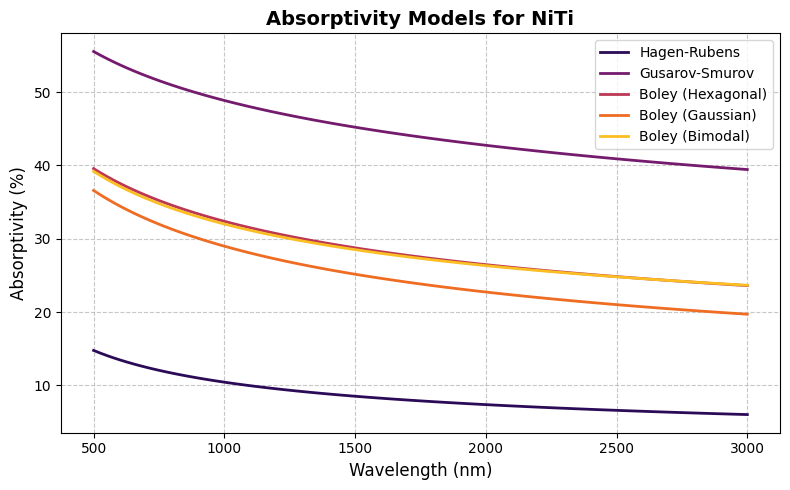

In [1]:
import numpy as np
from lpbf_map.materials import Material

niti = Material.from_library('NiTi_Sheikh')
wavelengths = np.linspace(0.5e-6, 3.0e-6, 100)

# The built-in method evaluates all 5 models and plots them automatically
fig, ax = niti.plot_absorptivity_models(wavelengths=wavelengths)
